REFER:

https://prakashsukhwal.github.io/IT5006/IT5006_Project_Description_2026Jan_V2.html

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/it5006/data/Crimes_2015-2025.csv", header=0)


data.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(2755560, 22)

In [7]:
# drop rows with missing value
missing = data[['Date', 'Latitude', 'Longitude']].isna().any(axis=1).sum()
print("Missing values:", missing)

data.dropna(subset=['Date', 'Latitude', 'Longitude'], inplace=True)

Missing values: 42185


In [8]:
# Convert time in the Date column to two new columns: Year, Month
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['DayOfWeek'] = data['Date'].dt.day_name()
data['Hour'] = data['Date'].dt.hour

data.head()

/tmp/ipython-input-4155349992.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,Month,DayOfWeek,Hour
0,14075483,JK105557,2025-12-31 23:58:00,050XX S PAULINA ST,0560,ASSAULT,SIMPLE,RESIDENCE,False,False,...,1165860.0,1871343.0,2025,01/09/2026 03:40:47 PM,41.802549,-87.667246,"(41.802549018, -87.667246428)",12,Wednesday,23
1,14070833,JK100050,2025-12-31 23:55:00,053XX W WASHINGTON BLVD,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,APARTMENT,False,True,...,1140809.0,1900235.0,2025,01/08/2026 03:46:48 PM,41.882329,-87.758411,"(41.882328854, -87.758411303)",12,Wednesday,23
2,14070745,JK100011,2025-12-31 23:54:00,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,...,1100658.0,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,"(41.976290414, -87.905227221)",12,Wednesday,23
3,14070845,JK100006,2025-12-31 23:54:00,013XX W LAKE ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",RESTAURANT,True,False,...,1167120.0,1901555.0,2025,01/08/2026 03:46:48 PM,41.885427,-87.661759,"(41.885426714, -87.661759042)",12,Wednesday,23
4,14070799,JK100014,2025-12-31 23:54:00,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,...,1100658.0,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,"(41.976290414, -87.905227221)",12,Wednesday,23


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2713375 entries, 0 to 2755559
Data columns (total 25 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Case Number           object        
 2   Date                  datetime64[ns]
 3   Block                 object        
 4   IUCR                  object        
 5   Primary Type          object        
 6   Description           object        
 7   Location Description  object        
 8   Arrest                bool          
 9   Domestic              bool          
 10  Beat                  int64         
 11  District              float64       
 12  Ward                  float64       
 13  Community Area        float64       
 14  FBI Code              object        
 15  X Coordinate          float64       
 16  Y Coordinate          float64       
 17  Year                  int32         
 18  Updated On            object        
 19  Latit

# Analyze Crime Distribution by Time

**Summary of Crime Distribution by Hour**

The bar chart above illustrates the crime distribution throughout the 24 hours of the day. Key observations include:

*   **Low Crime Hours:** The hours between 3 AM and 6 AM show the lowest number of reported crimes, suggesting a period of reduced criminal activity.
*   **Increasing Trend:** From 6 AM onwards, crime incidents begin to rise steadily.
*   **Peak Crime Hours:** The crime rate peaks significantly in the afternoon and early evening, specifically between **12 PM (noon)** and **6 PM**. There's a notable increase around noon, and a consistently high number of crimes are reported from 3 PM to 6 PM.
*   **Evening Decline:** After 6 PM, there's a gradual decrease in crime incidents, continuing into the late evening and early morning hours.

These findings suggest that criminal activity is most prevalent during daylight and early evening hours, likely coinciding with higher public activity and opportunities for certain types of offenses.

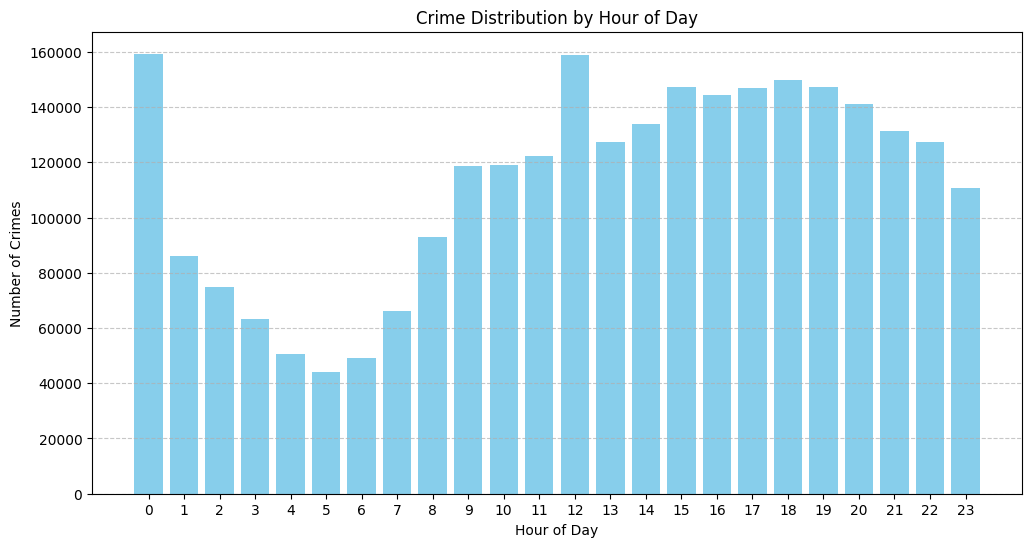

In [10]:
# By Hours

# Calculate the number of crimes for each hour
hourly_crime_counts = data['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(hourly_crime_counts.index, hourly_crime_counts.values, color='skyblue')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Crimes')
plt.title('Crime Distribution by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Summary of Crime Distribution by Day of Week

The bar chart above illustrates the crime distribution across different days of the week. Key observations include:

*   **Higher Crime on Weekends and Friday:** Friday and Saturday tend to have the highest number of reported crimes, suggesting an increase in criminal activity towards the end of the work week and during the weekend. Friday registers the highest number of crimes, closely followed by Saturday.
*   **Relatively Consistent Weekday Crime:** Crime counts remain relatively stable from Monday to Thursday, with slight fluctuations but no drastic drops or spikes.
*   **Lowest Crime Days:** While there isn't a significant drop, Sundays generally show a slightly lower crime count compared to Fridays and Saturdays, and sometimes even compared to some weekdays.

These findings suggest that criminal activity tends to increase as the week progresses, peaking on Friday and Saturday, possibly correlating with increased social activities and opportunities during these days.

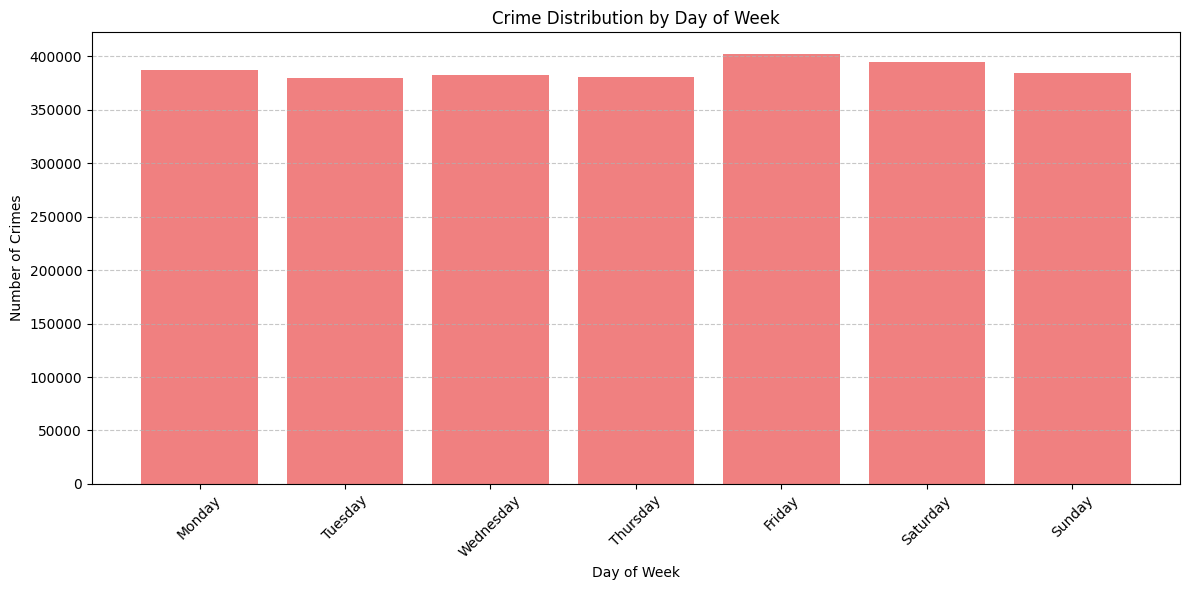

In [11]:
# By Week

# Calculate the number of crimes for each day of the week
daily_crime_counts = data['DayOfWeek'].value_counts()

# Define the desired order as index for days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_crime_counts = daily_crime_counts.reindex(day_order)

plt.figure(figsize=(12, 6))
plt.bar(daily_crime_counts.index, daily_crime_counts.values, color='lightcoral')
plt.xlabel('Day of Week')
plt.ylabel('Number of Crimes')
plt.title('Crime Distribution by Day of Week')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Summary of Crime Distribution by Month**

The bar chart above illustrates the crime distribution across different months of the year. Key observations include:

*   **Seasonal Peaks:** There is a clear pattern of increased crime during the summer months, specifically from **May to August**, with July often registering the highest number of incidents. This could be attributed to warmer weather, more outdoor activities, and potentially longer daylight hours.
*   **Gradual Increase and Decrease:** Crime rates tend to gradually increase starting from March, peak in the summer, and then gradually decrease towards the end of the year, with **November, December, January, and February** showing relatively lower crime counts.
*   **Lowest Crime Months:** January and February generally show the lowest numbers of reported crimes, likely due to colder weather limiting outdoor activities and opportunities for certain types of offenses.

These findings suggest a significant seasonal influence on crime rates, with a noticeable surge in criminal activity during the warmer months.

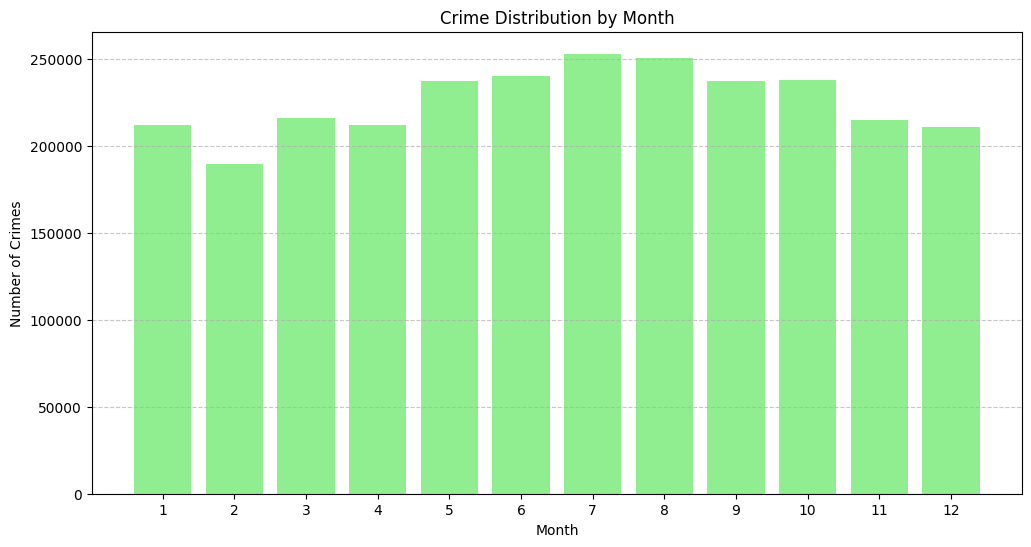

In [12]:
#By Month

# Calculate the number of crimes for each month and sort by month number
monthly_crime_counts = data['Month'].value_counts().sort_index()


plt.figure(figsize=(12, 6))
plt.bar(monthly_crime_counts.index, monthly_crime_counts.values, color='lightgreen')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.title('Crime Distribution by Month')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7);

plt.show()

**Summary of Crime Distribution by Year**

The line plot above illustrates the crime distribution across different years. Key observations include:

*   **Initial Decline (2015-2017):** There was a noticeable decline in crime numbers from 2015 to 2017.
*   **Relative Stability (2017-2019):** Crime rates remained relatively stable from 2017 to 2019.
*   **Sharp Drop (2019-2021):** A significant decrease in reported crimes occurred between 2019 and 2021, possibly influenced by factors such as the COVID-19 pandemic and associated lockdowns.
*   **Recent Increase (2021-2023):** Following the sharp drop, there has been a steady increase in crime incidents from 2021 to 2023, indicating a potential return to pre-pandemic levels or new trends.
*   **2024 and 2025 Data:** The data for 2024 and 2025 appear to be partial or projected, showing a dip or continuation of recent trends which might not reflect the full year's actual crime rates. It's important to consider that the dataset might not contain complete data for the current or future years.

These findings suggest dynamic changes in crime patterns over the years, with notable shifts during the pandemic period and subsequent recovery.

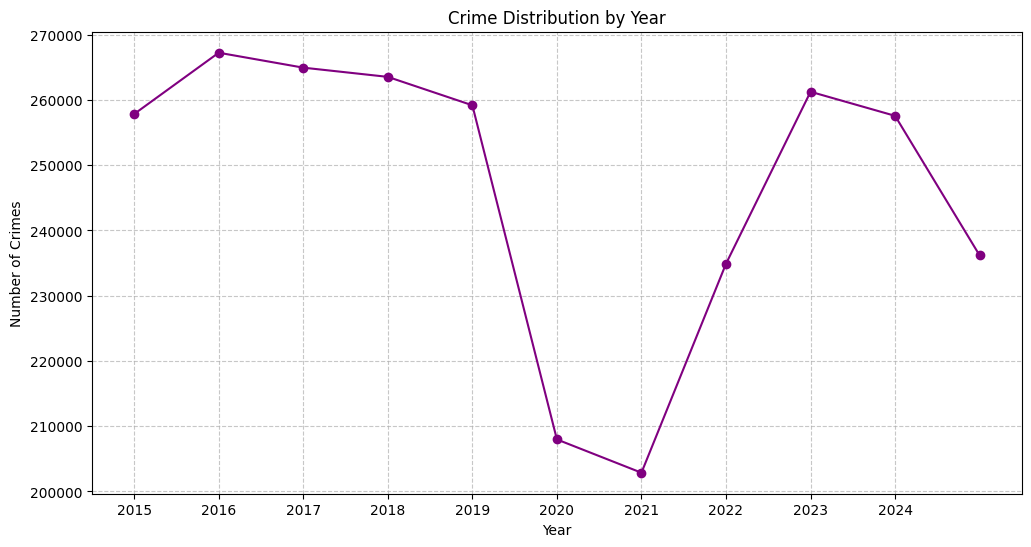

In [13]:
#By Year

# Calculate the number of crimes for each year and sort by year
yearly_crime_counts = data['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(yearly_crime_counts.index, yearly_crime_counts.values, marker='o', color='purple')
plt.xticks(range(2015, 2025))
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.title('Crime Distribution by Year')
plt.grid(axis='both', linestyle='--', alpha=0.7)

plt.show()

**Summary:**


The key findings from the temporal pattern analysis of crimes indicate specific high-frequency periods across different time scales:
*   **Hourly**: The highest crime activity occurs in the afternoon and early evening, specifically between 12 PM (noon) and 6 PM, with 3 PM to 6 PM showing consistently high numbers. The lowest crime hours are between 3 AM and 6 AM.
*   **Daily**: Crimes are most frequent towards the end of the week, with Friday and Saturday exhibiting the highest number of reported incidents; Friday often registers as the peak day. Weekdays from Monday to Thursday show relatively consistent crime levels.
*   **Monthly**: There is a clear seasonal increase in crime during the summer months, particularly from May to August, with July frequently recording the highest number of incidents. January and February typically show the lowest crime counts.
*   **Yearly**: High crime counts were observed from 2015 to 2019. A significant drop occurred between 2019 and 2021 (potentially due to the COVID-19 pandemic), followed by a steady increase from 2021 to 2023, approaching pre-pandemic levels. Data for 2024 and 2025 appear partial.

**Data Analysis Key Findings**
*   Crime distribution by hour shows a significant peak in the afternoon and early evening, specifically between 12 PM (noon) and 6 PM, with the period from 3 PM to 6 PM consistently reporting high crime numbers.
*   The lowest crime activity occurs between 3 AM and 6 AM.
*   Crime distribution by day of the week indicates higher criminal activity on weekends and Friday, with Friday and Saturday having the highest number of reported crimes.
*   Weekday crime levels (Monday to Thursday) remain relatively stable.
*   Crime distribution by month reveals a clear seasonal pattern, with increased incidents during the summer months (May to August), and July often being the peak month.
*   The lowest crime counts are typically observed in January and February.
*   Crime distribution by year shows a decline from 2015 to 2017, relative stability from 2017 to 2019, followed by a sharp drop between 2019 and 2021.
*   A recent increase in crime incidents has been observed from 2021 to 2023, potentially approaching pre-pandemic levels, with 2023 having the highest crime count since the pandemic-related drop.
*   Overall, the high-frequency crime periods are identified as afternoon and early evening (12 PM - 6 PM), Fridays and Saturdays, and during the summer months (May - August).


# Analyze Crime Distribution By Space

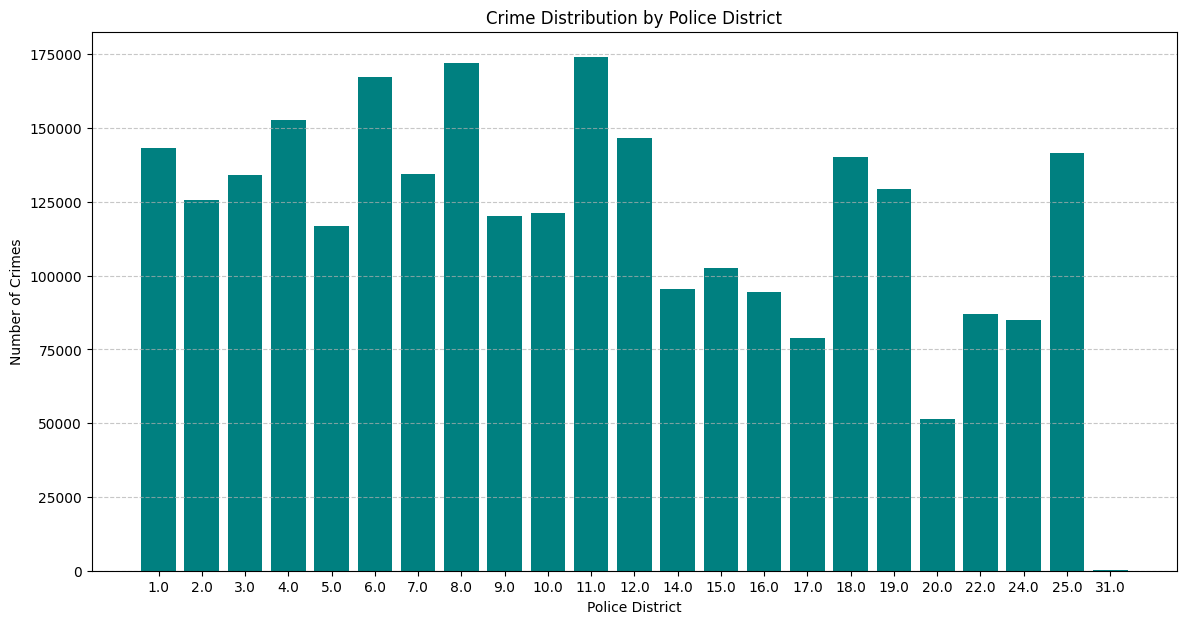

In [14]:
# By District

# Calculate the number of crimes for each police district
district_crime_counts = data['District'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
plt.bar(district_crime_counts.index.astype(str), district_crime_counts.values, color='teal')
plt.xlabel('Police District')
plt.ylabel('Number of Crimes')
plt.title('Crime Distribution by Police District')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

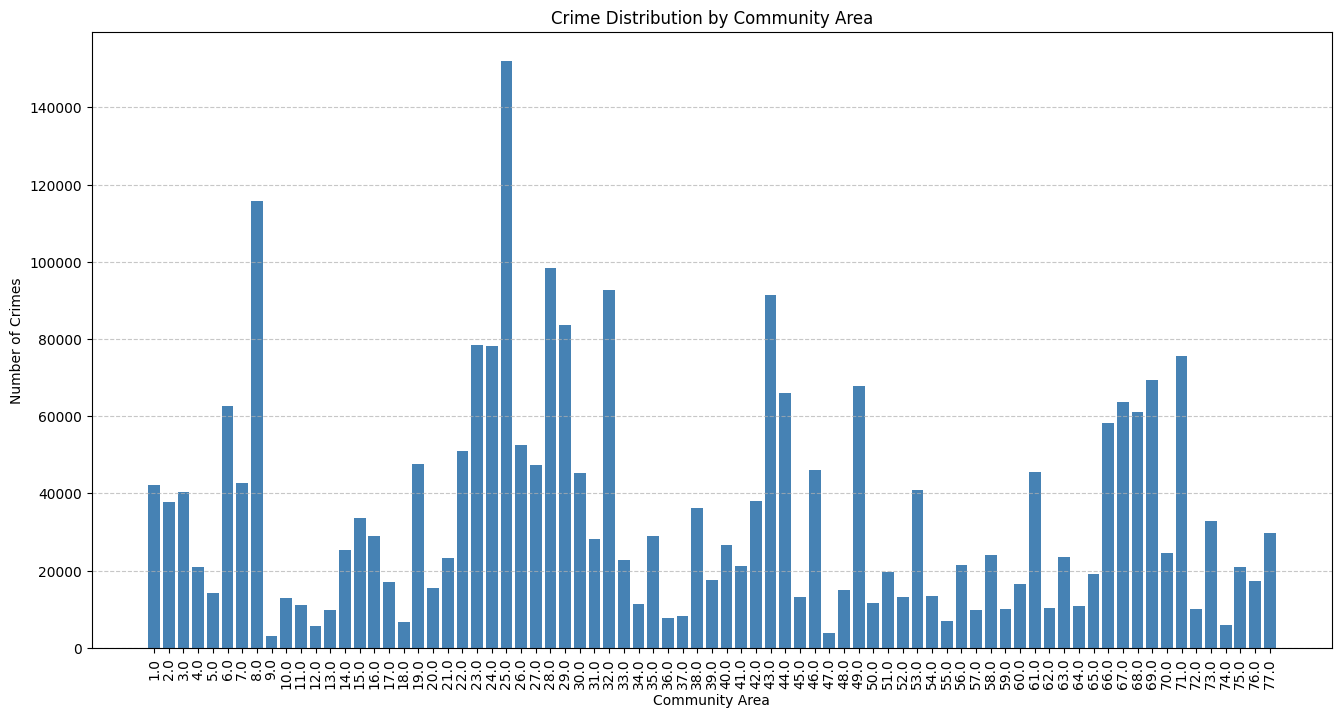

In [15]:
# By Community Area

# Calculate the number of crimes for each community area (already available in kernel as community_area_crime_counts)
community_area_crime_counts = data['Community Area'].value_counts().sort_index()

plt.figure(figsize=(16, 8))
plt.bar(community_area_crime_counts.index.astype(str), community_area_crime_counts.values, color='steelblue')
plt.xlabel('Community Area')
plt.ylabel('Number of Crimes')
plt.title('Crime Distribution by Community Area')
plt.xticks(rotation=90, ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

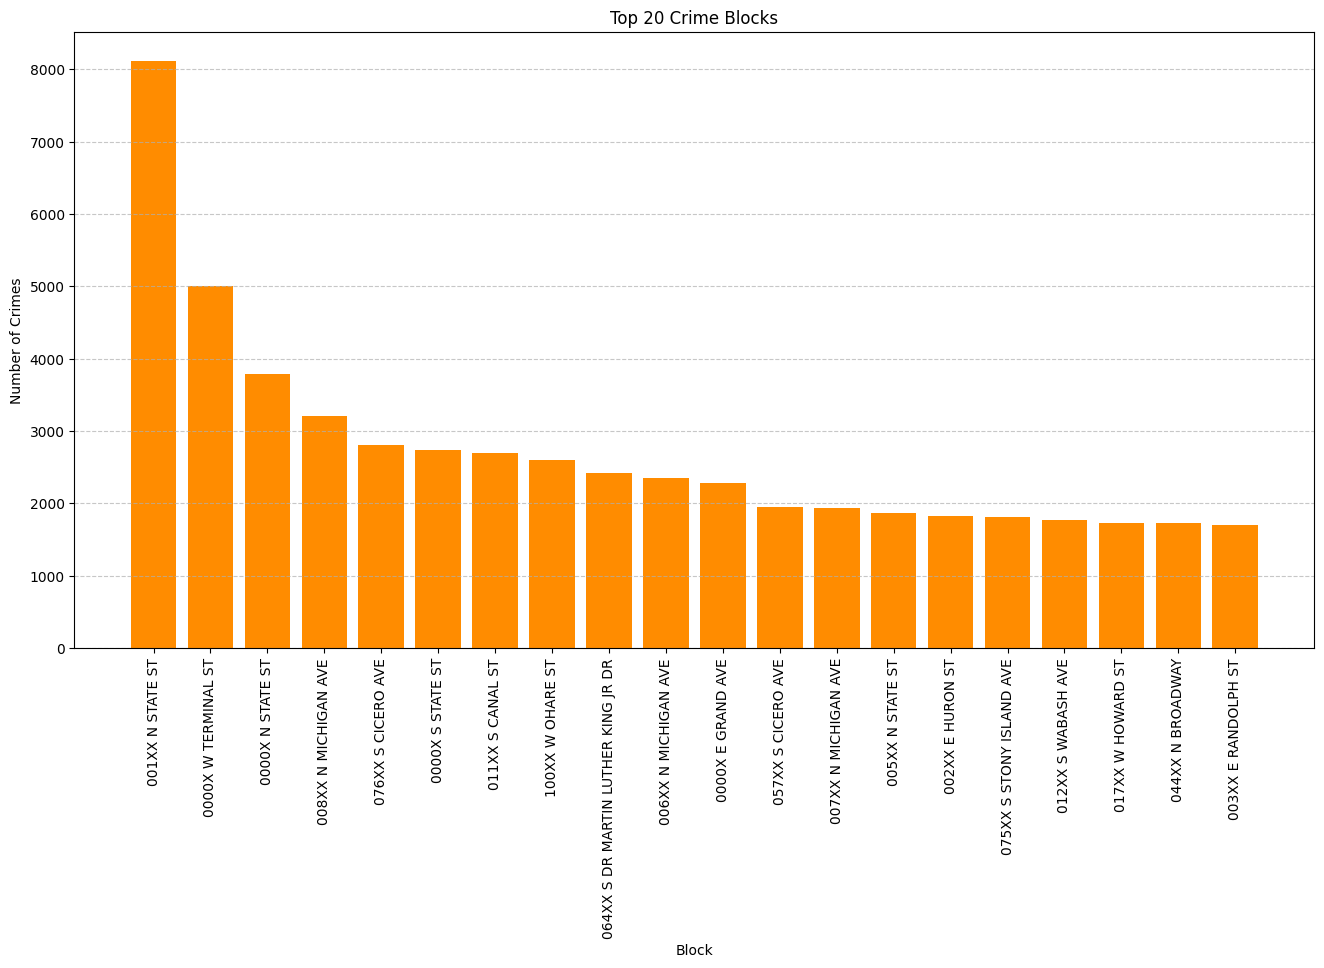

In [16]:
# By Block
top_n = 20

# Compute block_crime_counts
block_crime_counts = data['Block'].value_counts()

# Select the top N blocks with the highest number of crimes
top_n_blocks = block_crime_counts.head(top_n)

plt.figure(figsize=(16, 8))
plt.bar(top_n_blocks.index, top_n_blocks.values, color='darkorange')
plt.xlabel('Block')
plt.ylabel('Number of Crimes')
plt.title(f'Top {top_n} Crime Blocks')
plt.xticks(rotation=90, ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

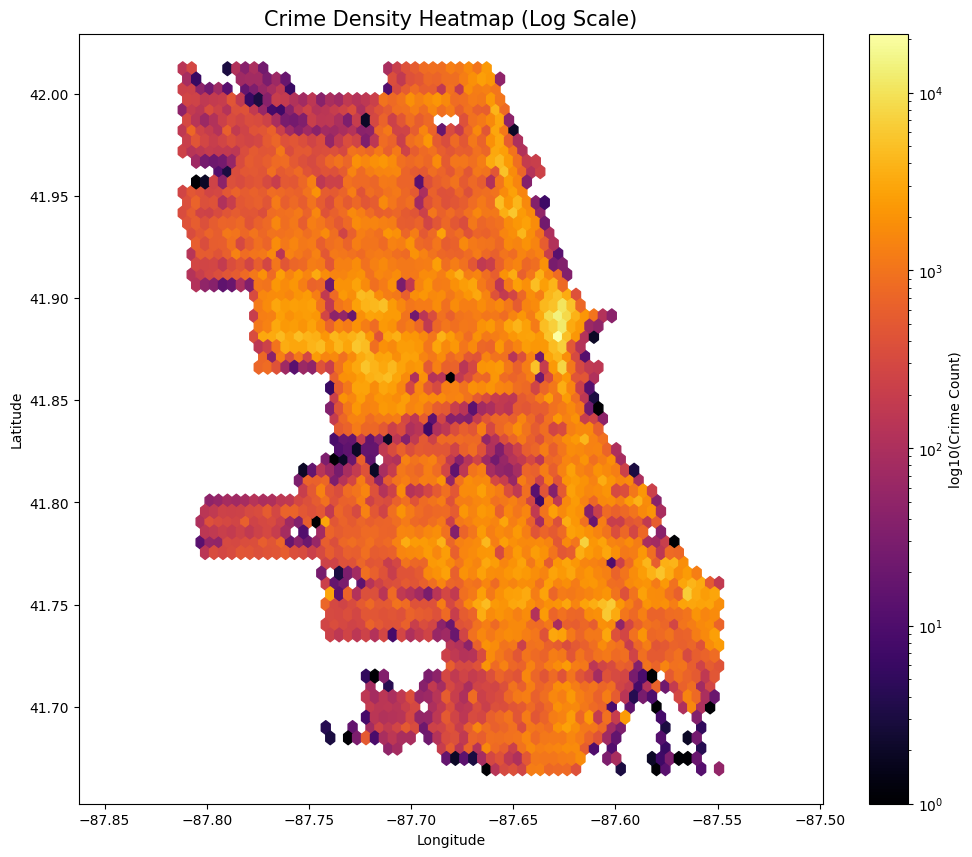

In [21]:
import matplotlib.pyplot as plt

lon_min, lon_max = data['Longitude'].quantile([0.01, 0.99])
lat_min, lat_max = data['Latitude'].quantile([0.01, 0.99])

plt.figure(figsize=(12, 10))


hb = plt.hexbin(data['Longitude'], data['Latitude'],
                gridsize=60,
                cmap='inferno',
                bins='log',
                mincnt=1,
                extent=[lon_min, lon_max, lat_min, lat_max])

cb = plt.colorbar(hb, label='log10(Crime Count)')

plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.title('Crime Density Heatmap (Log Scale)', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.axis('equal')

plt.show()


**Summary:**


*   **Police Districts:** District 11.0 and District 8.0 recorded the highest crime counts. In contrast, District 31.0 had a significantly low crime count, with only 117 incidents.
*   **Community Areas:** Community Area 25.0 and Community Area 8.0 showed the highest number of reported crimes, while Community Area 74.0 consistently had one of the lowest crime counts.
*   **Specific Blocks:** The blocks `001XX N STATE ST`, `0000X W TERMINAL ST`, and `0000X N STATE ST` were identified as among the top locations with the highest crime rates.
*   **Spatial Concentration:** Crime is not uniformly distributed across Chicago; instead, it is concentrated in specific districts, community areas, and individual blocks. These high-frequency areas are often associated with significant commercial activity, dense populations, or specific socioeconomic factors.


# Crime Correlation Analysis

3.1 Association between Crime Types and Locations

1. Methodology (Observation Method) We utilized Cross-tabulation (Crosstab) analysis on the top 12 crime types and location descriptions to identify environmental dependencies. To provide a comprehensive view, we generated two distinct heatmaps: a Row-Normalized view to identify where specific crimes occur, and a Column-Normalized view to assess the risk profile of specific locations.

2. Observed Phenomena The analysis reveals three distinct clusters:

Commercial Concentration: Theft is almost exclusively concentrated in 'Department Stores', 'Grocery Stores', and 'Small Retail Stores'.

Private vs. Public Violence: Battery and Assault predominantly occur in private spaces like 'Apartments' and 'Residences', whereas Robbery is heavily clustered on public 'Sidewalks' and 'Streets'.

High-Risk Public Ways: The Column-Normalized view highlights that 'Streets' are the most volatile environment, hosting a diverse range of crimes including Motor Vehicle Theft and Weapons Violations.

3. Possible Causes These patterns indicate that Theft is driven by commercial opportunity, whereas Battery is largely rooted in private interpersonal or domestic disputes rather than random street violence. Conversely, Robbery and Vehicle Theft are predatory in nature, relying on the traffic flow and escape routes provided by public infrastructure.

4. Business & Policing Recommendations A segmented policing strategy is required:

Commercial Zones: Focus on partnerships with private security for loss prevention rather than heavy active patrolling.

Residential Zones: Shift towards Community Policing and social service integration to intervene in domestic disputes before they escalate to Battery.

Public Ways: Prioritize visible deterrence (foot patrols) and deploy technology like License Plate Readers (LPRs) on streets to combat the high volume of vehicular and predatory crimes.

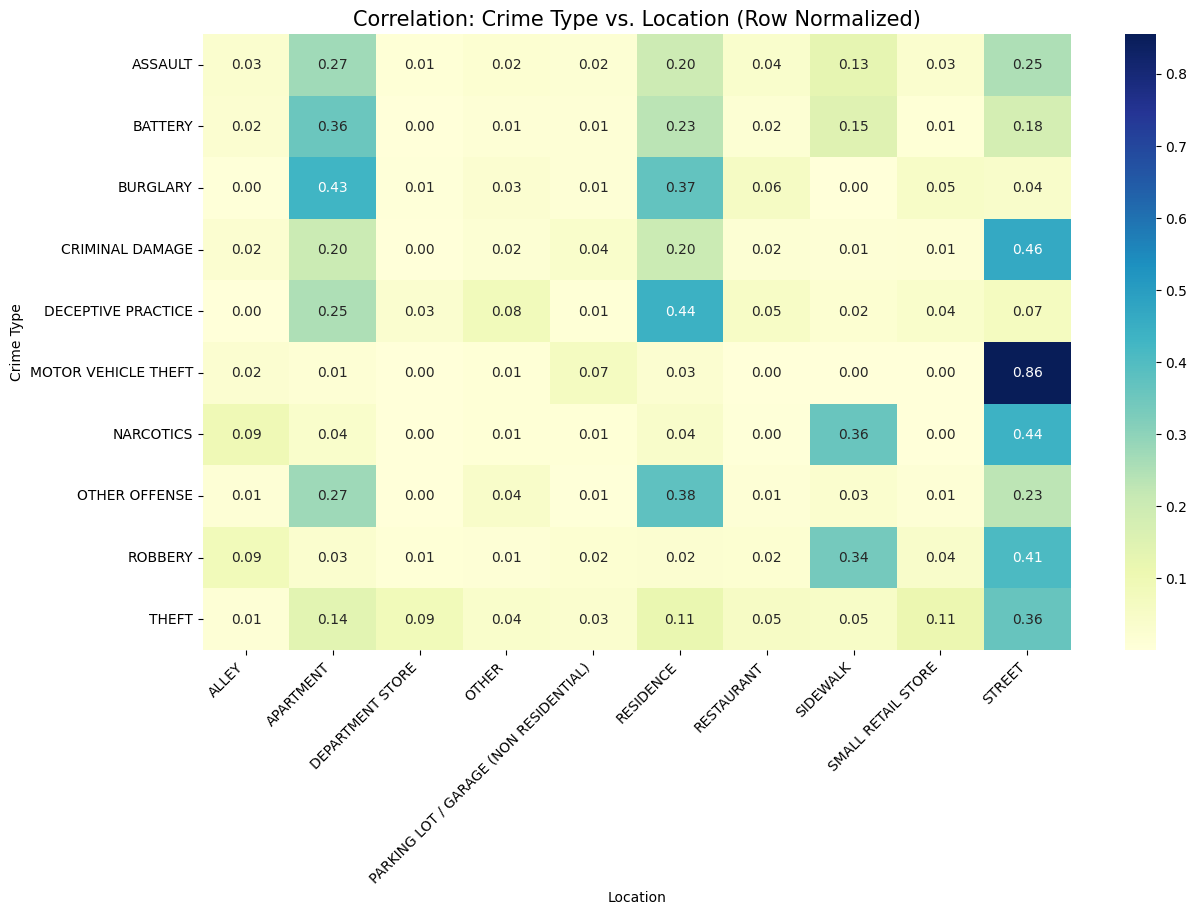

In [22]:
import seaborn as sns

top_crimes = data['Primary Type'].value_counts().head(10).index
top_locations = data['Location Description'].value_counts().head(10).index

df_subset = data[data['Primary Type'].isin(top_crimes) &
                 data['Location Description'].isin(top_locations)]


crime_loc_matrix = pd.crosstab(df_subset['Primary Type'],
                               df_subset['Location Description'],
                               normalize='index')

plt.figure(figsize=(14, 8))
sns.heatmap(crime_loc_matrix, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Correlation: Crime Type vs. Location (Row Normalized)', fontsize=15)
plt.ylabel('Crime Type')
plt.xlabel('Location')
plt.xticks(rotation=45, ha='right')
plt.show()

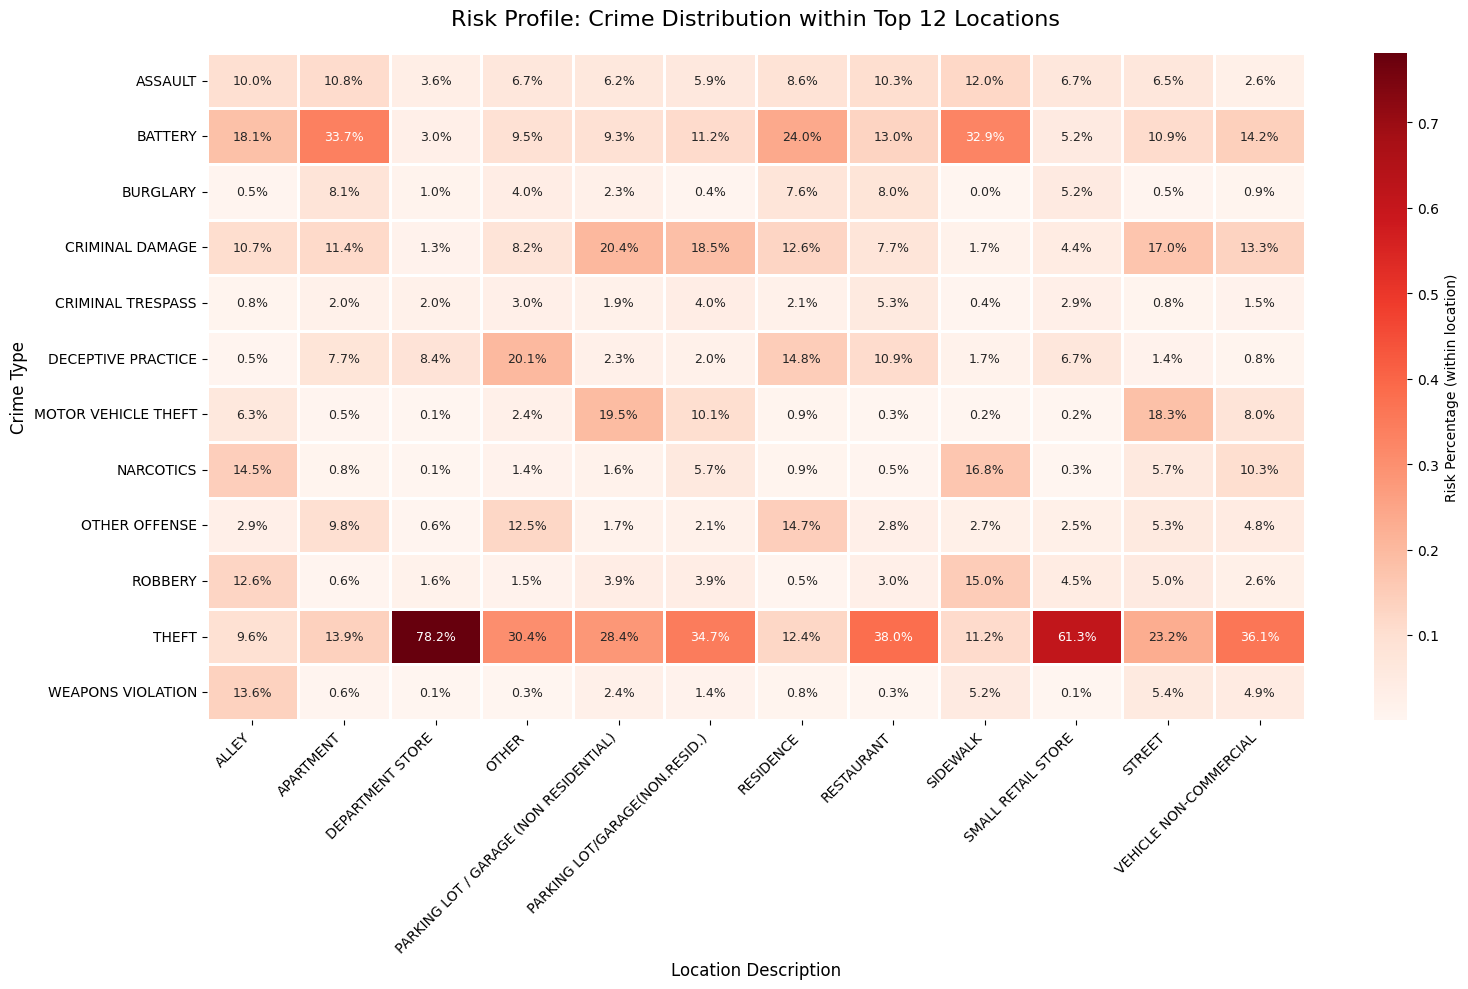

In [29]:
top_n = 12
top_crimes = data['Primary Type'].value_counts().head(top_n).index
top_locations = data['Location Description'].value_counts().head(top_n).index

df_clean = data[data['Primary Type'].isin(top_crimes) &
                data['Location Description'].isin(top_locations)]

crime_loc_matrix_col = pd.crosstab(df_clean['Primary Type'],
                                   df_clean['Location Description'],
                                   normalize='columns')

plt.figure(figsize=(16, 10))

sns.heatmap(crime_loc_matrix_col,
            annot=True,
            fmt='.1%',
            cmap='Reds',
            linewidths=1,
            linecolor='white',
            annot_kws={"size": 9},
            cbar_kws={'label': 'Risk Percentage (within location)'})

plt.title(f'Risk Profile: Crime Distribution within Top {top_n} Locations', fontsize=16, pad=20)
plt.ylabel('Crime Type', fontsize=12)
plt.xlabel('Location Description', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

3.2 Enforcement Efficiency Analysis (Crime Type vs. Arrest Rate)

1. Methodology (Observation Method) We calculated the Arrest Rate (percentage of incidents where Arrest == True) for the top 15 most frequent crime types. The results are visualized in a horizontal bar chart, color-coded to highlight critical enforcement gaps where clearance rates fall below 15%.

2. Observed Phenomena The analysis reveals a stark polarization in enforcement efficiency:

Proactive Crimes: Offenses like Narcotics and Weapons Violations show near-perfect arrest rates (>90%).

Reactive Crimes: High-volume property crimes, specifically Motor Vehicle Theft and Burglary, consistently display alarmingly low clearance rates (<10%).

Violent Crimes: Offenses like Battery and Assault sit in the middle ground (20-30%), meaning the majority of these cases do not result in an immediate arrest.

3. Possible Causes High arrest rates in Narcotics reflect officer-initiated activity (the crime is recorded only upon arrest), whereas low rates in property crime stem from their victim-reported nature, where offenders typically flee before police arrival. The moderate rates for violence often result from the complexity of gathering evidence or victims declining to prosecute in domestic situations.

4. Business & Policing Recommendations

Investigative Shift: For low-clearance property crimes, resources should divert from random patrols to investigative units and forensic technology (e.g., latent prints).

Technology Multiplier: Deploy Automated License Plate Recognition (ALPR) to combat the low clearance rate of Motor Vehicle Theft.

KPI Adjustment: Performance metrics should deprioritize raw arrest counts for "Proactive Crimes" to avoid inflating statistics through aggressive stops.

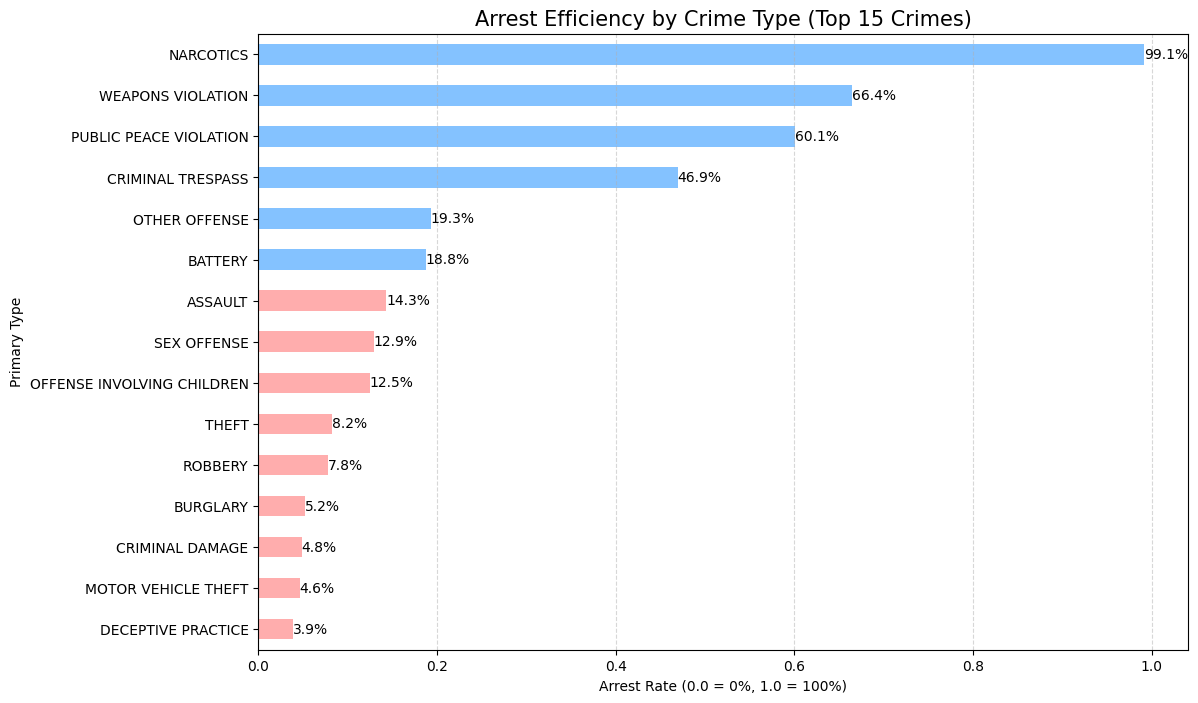

In [23]:
arrest_rates = data.groupby('Primary Type')['Arrest'].mean().sort_values(ascending=False)

top_15_types = data['Primary Type'].value_counts().head(15).index
arrest_rates_top15 = arrest_rates[top_15_types].sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = ['#ff9999' if x < 0.15 else '#66b3ff' for x in arrest_rates_top15]
arrest_rates_top15.plot(kind='barh', color=colors, alpha=0.8)

plt.title('Arrest Efficiency by Crime Type (Top 15 Crimes)', fontsize=15)
plt.xlabel('Arrest Rate (0.0 = 0%, 1.0 = 100%)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

for index, value in enumerate(arrest_rates_top15):
    plt.text(value, index, f'{value:.1%}', va='center')

plt.show()

3.3 Temporal-Specific Crime Schedules (Crime Type vs. Hour of Day)

1. Methodology (Observation Method) We utilized a Row-Normalized Heatmap to visualize the hourly probability distribution for the Top 10 crime types across a 24-hour cycle. This approach highlights the distinct "work schedules" of different criminal activities by mapping their specific peak activity windows.

2. Observed Phenomena The analysis reveals three distinct temporal clusters:

"Business Hour" Crimes: Theft and Deceptive Practice mirror the standard 9-to-5 workday, tapering off significantly after sunset.

"Nocturnal" Violence: Battery and Weapons Violations remain low during the day but climb rapidly after 16:00, peaking between 20:00 and 02:00.

"Commuter" Peak: Robbery displays a unique, sharp spike during the evening twilight transition (17:00 - 21:00), diverging from the steady daytime pattern of simple theft.

3. Possible Causes Property crimes are "opportunity-driven," depending on open businesses and active crowds. Conversely, violent crimes correlate with nightlife factors (alcohol consumption, lower guardianship), while Robbery specifically capitalizes on the vulnerability of commuters returning home during the transition from daylight to darkness.

4. Business & Policing Recommendations We recommend moving from static shifts to Activity-Based Rostering:

Financial Units should align strictly with banking hours (08:00 - 17:00).

Violent Crime Task Forces should implement a staggered "Power Shift" (18:00 - 04:00) to cover the entire nightly peak.

Patrol Units must increase density near transit hubs during the 17:00 - 21:00 window to suppress the commuter robbery spike.

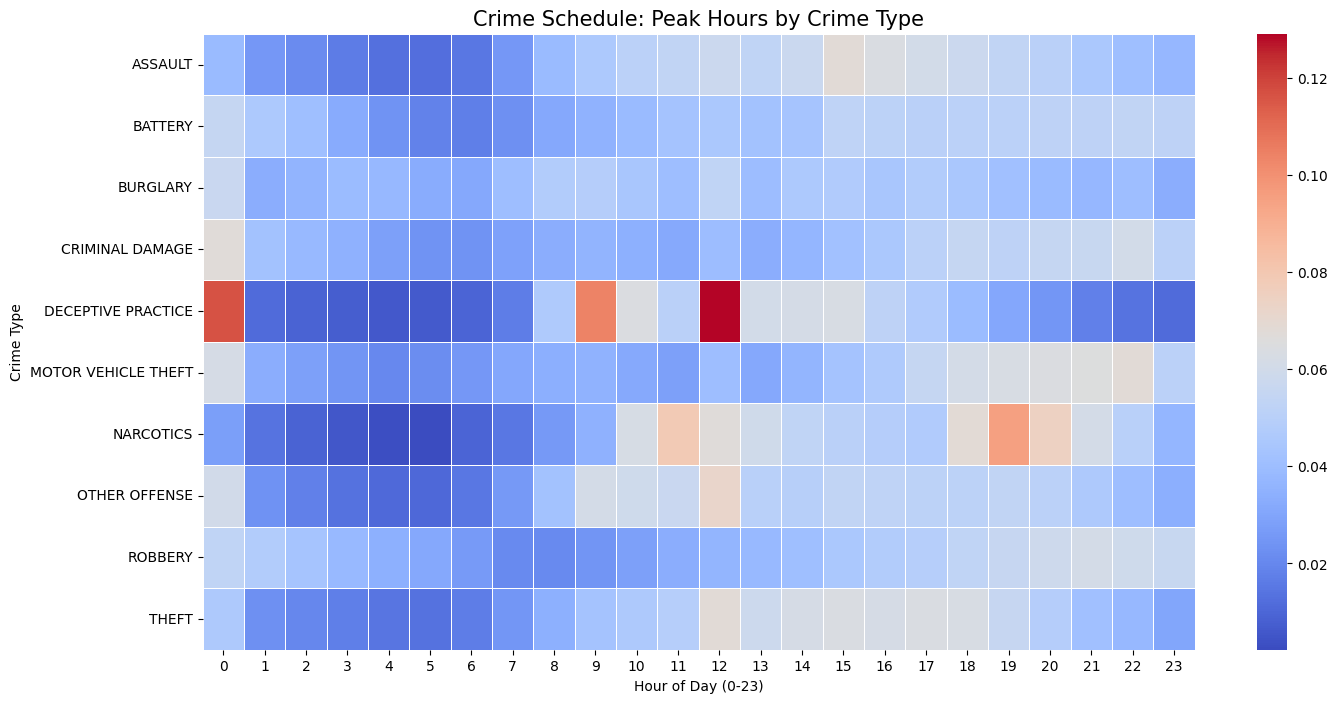

In [24]:
top_crimes = data['Primary Type'].value_counts().head(10).index
df_subset = data[data['Primary Type'].isin(top_crimes)]

time_crime_matrix = pd.crosstab(df_subset['Primary Type'],
                                df_subset['Hour'],
                                normalize='index')

plt.figure(figsize=(16, 8))
sns.heatmap(time_crime_matrix, cmap='coolwarm', linewidths=0.5)
plt.title('Crime Schedule: Peak Hours by Crime Type', fontsize=15)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Crime Type')
plt.show()

3.4 Domestic Violence Characteristics (Domestic vs. Crime Type)

1. Methodology (Observation Method) We filtered the dataset for the Top 50 most frequent crime types to exclude statistical noise from rare anomalies. We then calculated the Domestic Incident Rate (percentage of incidents flagged as Domestic == True) to identify which common crimes are driven by interpersonal relationships rather than predatory intent.

2. Observed Phenomena The analysis reveals that Battery and Assault have a substantial domestic component (approx. 40-50%), contradicting the assumption that they are purely "street crimes." Furthermore, specific offenses like Stalking, Offense Involving Children, and Criminal Damage appear at the top of the list, indicating they are heavily linked to household disputes.

3. Possible Causes These crimes stem from intimate partner violence and family disputes occurring in private residences where "capable guardianship" (police presence) is absent. Notably, Domestic Criminal Damage often serves as a psychological precursor or "red flag" for escalating violence (e.g., breaking a partner's phone) rather than simple property destruction.

4. Business & Policing Recommendations

Co-Responder Model: Deploy social workers alongside officers for high-risk domestic calls to focus on de-escalation.

Early Warning System: Treat "Domestic Criminal Damage" calls as high-priority risk indicators for future physical violence.

Data Segmentation: For predictive modeling, Domestic Battery and Street Battery must be treated as separate target variables due to their fundamentally different spatial and temporal patterns.

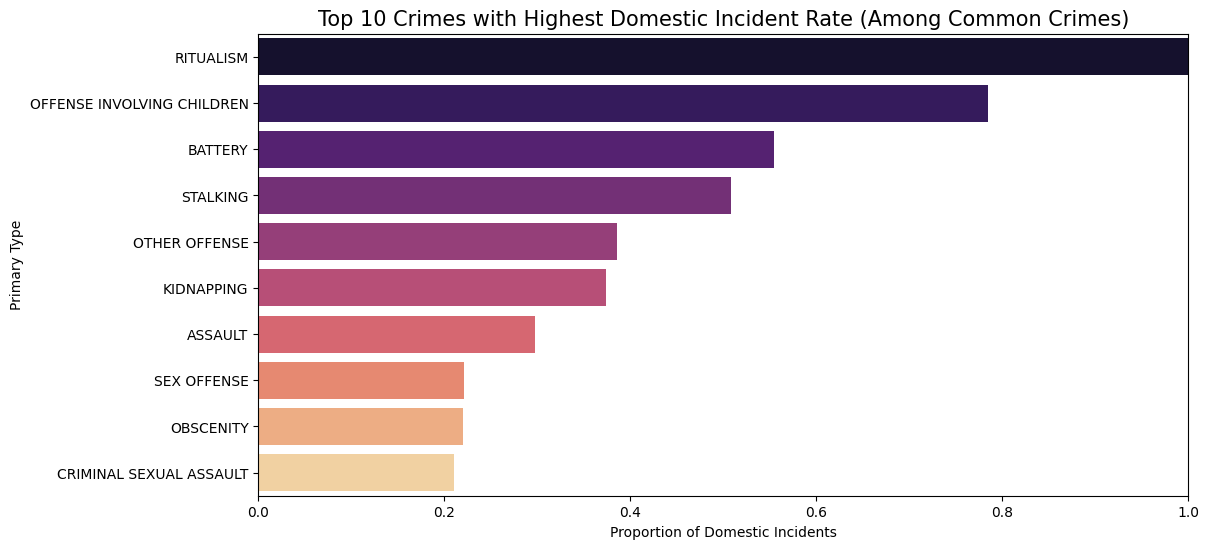

In [27]:
common_crimes = data['Primary Type'].value_counts().head(50).index

domestic_rates = data[data['Primary Type'].isin(common_crimes)].groupby('Primary Type')['Domestic'].mean().sort_values(ascending=False)

top_domestic = domestic_rates.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_domestic.values, y=top_domestic.index, palette='magma', hue=top_domestic.index, legend=False)
plt.title('Top 10 Crimes with Highest Domestic Incident Rate (Among Common Crimes)', fontsize=15)
plt.xlabel('Proportion of Domestic Incidents')
plt.xlim(0, 1)
plt.show()

3.5 Seasonal Interactions (Seasonality x Crime Type)
1. Methodology (Observation Method) We selected four distinct crime typologies (Battery, Theft, Deceptive Practice, Robbery) and plotted their monthly frequency trends. This comparative analysis reveals how different offenses react to environmental changes (Temperature/Seasons) to inform dynamic resource allocation.

2. Observed Phenomena The analysis reveals three distinct seasonal patterns:

"Temperature Theory" of Violence: Battery exhibits a textbook "Bell Curve," peaking significantly in July and August and hitting a trough in February.

"Holiday Effect": Robbery follows the summer trend but uniquely sustains or spikes again in November and December, diverging from other violent crimes.

Non-Seasonal Fraud: Deceptive Practice shows a flat trend line, demonstrating minimal sensitivity to weather changes compared to street crimes.

3. Possible Causes Battery correlates with rising temperatures and outdoor social interactions (the "Temperature Aggression Theory"). Conversely, Robbery's winter persistence is driven by the "Holiday Shopping Season" (cash circulation, early darkness), while Fraud is an indoor crime driven by economic cycles rather than weather.

4. Business & Policing Recommendations

Summer Surge (May-Sep): Maximize street presence in parks and outdoor venues to mitigate the heat-driven spike in Battery.

Winter Strategy (Nov-Jan): Shift resources to Commercial Corridor Patrols to protect holiday shoppers from Robbery.

Operational Efficiency: Schedule training academies and administrative downtime during February, the statistical low point for total crime.

<Figure size 1400x600 with 0 Axes>

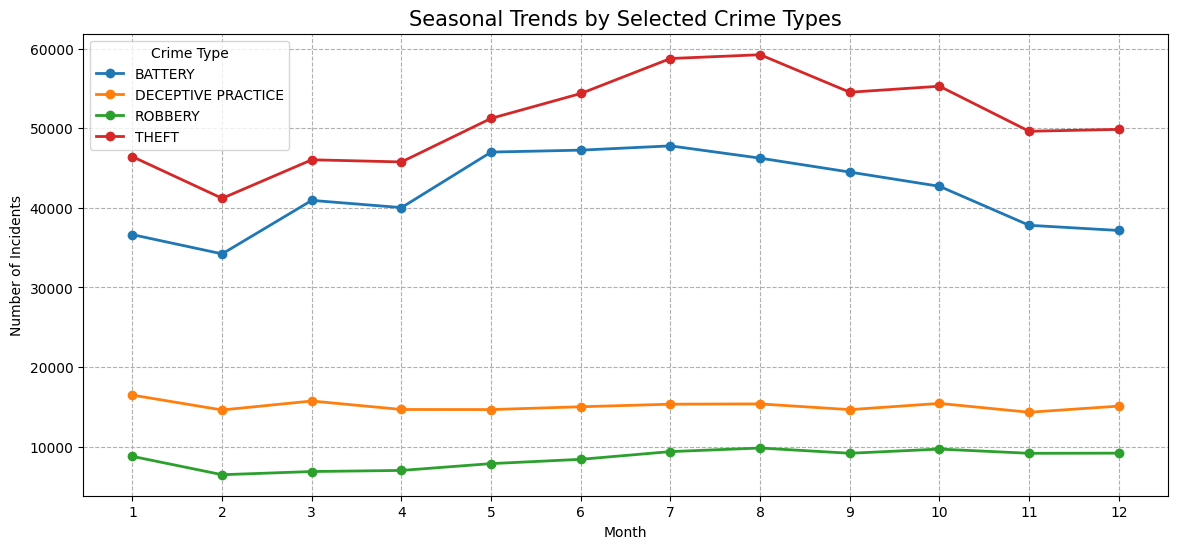

In [26]:
target_crimes = ['BATTERY', 'THEFT', 'DECEPTIVE PRACTICE', 'ROBBERY']

monthly_trends = data[data['Primary Type'].isin(target_crimes)].groupby(['Month', 'Primary Type']).size().unstack()

plt.figure(figsize=(14, 6))
monthly_trends.plot(kind='line', marker='o', linewidth=2, figsize=(14, 6))
plt.title('Seasonal Trends by Selected Crime Types', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--')
plt.legend(title='Crime Type')
plt.show()